In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib ipympl

import numpy as np
import maptools
import os

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from multiprocessing import Pool
from skimage.transform import iradon

maptools.job.info()
maptools.plot.dark()
!which python

import h5py
import ImageD11.columnfile
import ImageD11.sinograms.dataset
import ImageD11.sinograms.point_by_point
import matplotlib.pyplot as plt
import numpy as np

hostname: offline-cn12
SLURM_JOB_ID: 464506
SLURM_JOB_NODELIST: offline-cn12
NPROCS: 48
Memory available: 110.309433344 GB
/sw/jupyterhub/jupyterhub-hpc-node/conda/envs/lab-stable/bin/python


In [2]:
h5path = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/strong_pks.h5' )
parpath = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/al1050.par' )
colf = maptools.io.read_peaks(h5path, parpath)
colf.updateGeometry()

copied an array: size=44189043, elsize=4
copied an array: size=44189043, elsize=4
copied an array: size=44189043, elsize=4


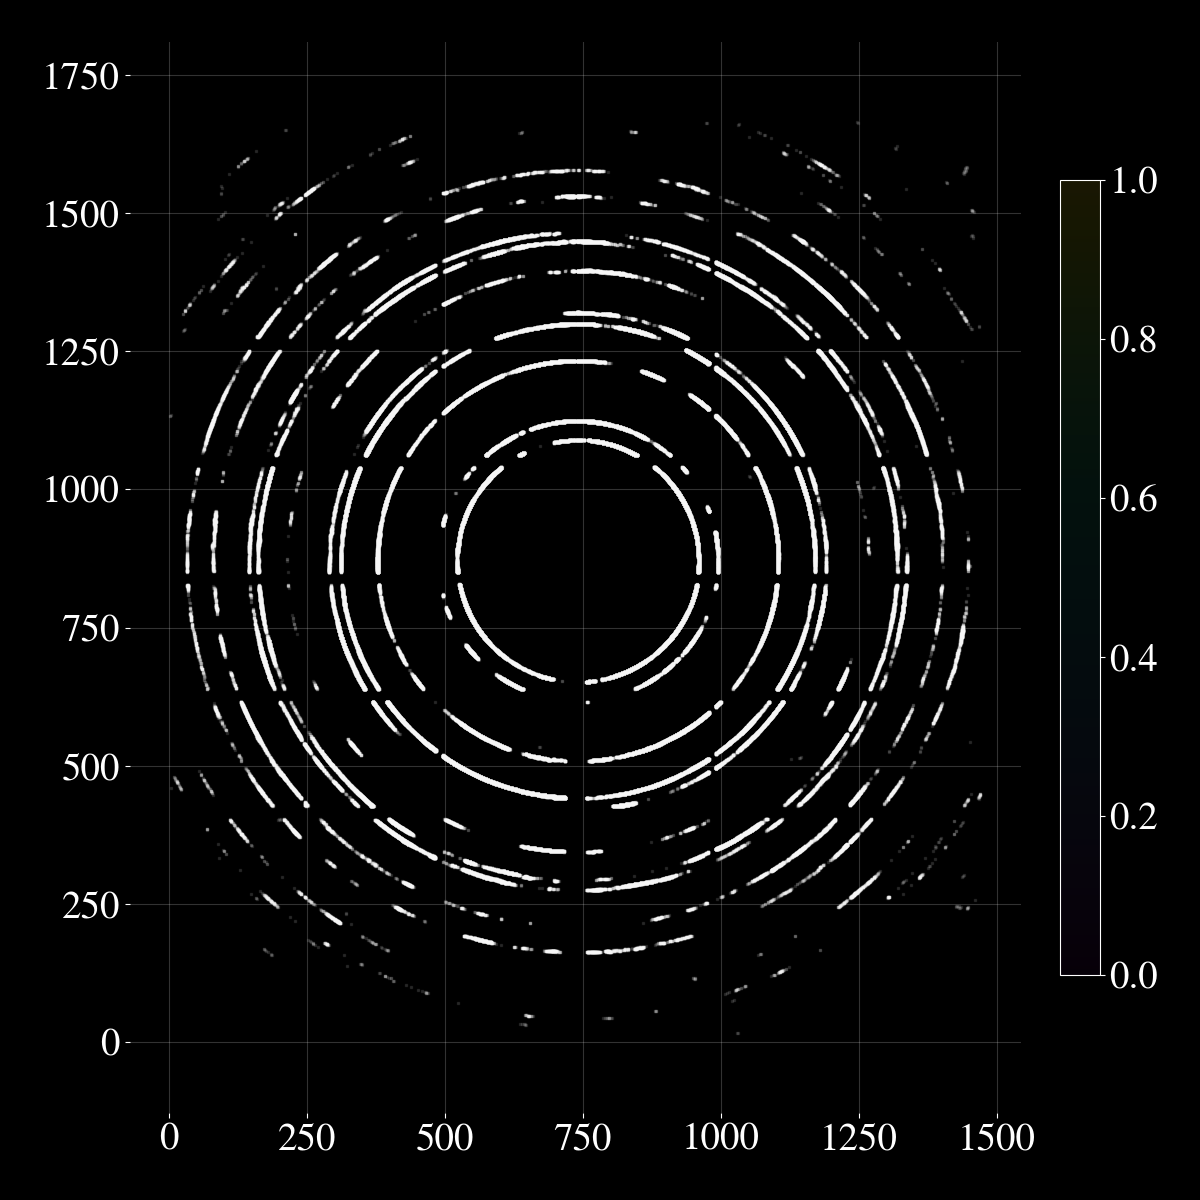

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
im = ax.scatter(colf.fc[colf.omega < 5], colf.sc[colf.omega < 5], marker=",", s=1, alpha=0.1, c='w')
fig.colorbar(im, ax=ax, fraction=0.041, pad=0.04)
ax.grid(True, alpha=0.2)
plt.axis("equal")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

In [4]:
a = colf.parameters.parameters["cell__a"]
b = colf.parameters.parameters["cell__b"]
c = colf.parameters.parameters["cell__c"]
alpha = colf.parameters.parameters["cell_alpha"]
beta = colf.parameters.parameters["cell_beta"]
gamma = colf.parameters.parameters["cell_gamma"]
symmetry = colf.parameters.parameters["cell_lattice_[P,A,B,C,I,F,R]"]
lattice_parameters = [a, b, c, alpha, beta, gamma]
ucell = ImageD11.unitcell.unitcell(lattice_parameters, symmetry)
ucell.makerings(colf.ds.max())

indexer = ImageD11.indexing.indexer_from_colfile(colf)
print(f"Indexing {colf.nrows} peaks")
indexer_ds_tol = 0.01
indexer.ds_tol = indexer_ds_tol

ImageD11.indexing.loglevel = 1
indexer.assigntorings()
ImageD11.indexing.loglevel = 3

info: gv: [[-0.26029091 -0.62463564  1.00158719]
 [-0.21694844  0.47220544  0.97352856]
 [-0.03250545 -0.327325    0.27251693]
 ...
 [-0.33307446  1.2739239   0.17562974]
 [-0.33290722  1.27414265  0.17159008]
 [-0.33179847  1.27187041  0.17300025]] (44189043, 3) float64
Indexing 44189043 peaks
info: Assign to rings, maximum d-spacing considered: 1.843150
info: Ring assignment array shape (44189043,)
info: Ring     (  h,  k,  l) Mult  total indexed to_index  ubis  peaks_per_ubi   tth
info: Ring 19  ( -4, -6, -2)   48      3       0        3     0     96  38.40
info: Ring 18  (  0, -4, -6)   24      6       0        6     0     48  36.95
info: Ring 17  ( -1, -5, -5)   48     26       0       26     0     96  36.58
info: Ring 16  ( -4, -4, -4)    8     29       0       29     1     16  35.45
info: Ring 15  ( -2, -6, -2)   24    723       0      723    15     48  33.89
info: Ring 14  ( -3, -5, -3)   24   1489       0     1489    30     48  33.50
info: Ring 13  ( -6,  0, -2)   24   3680   

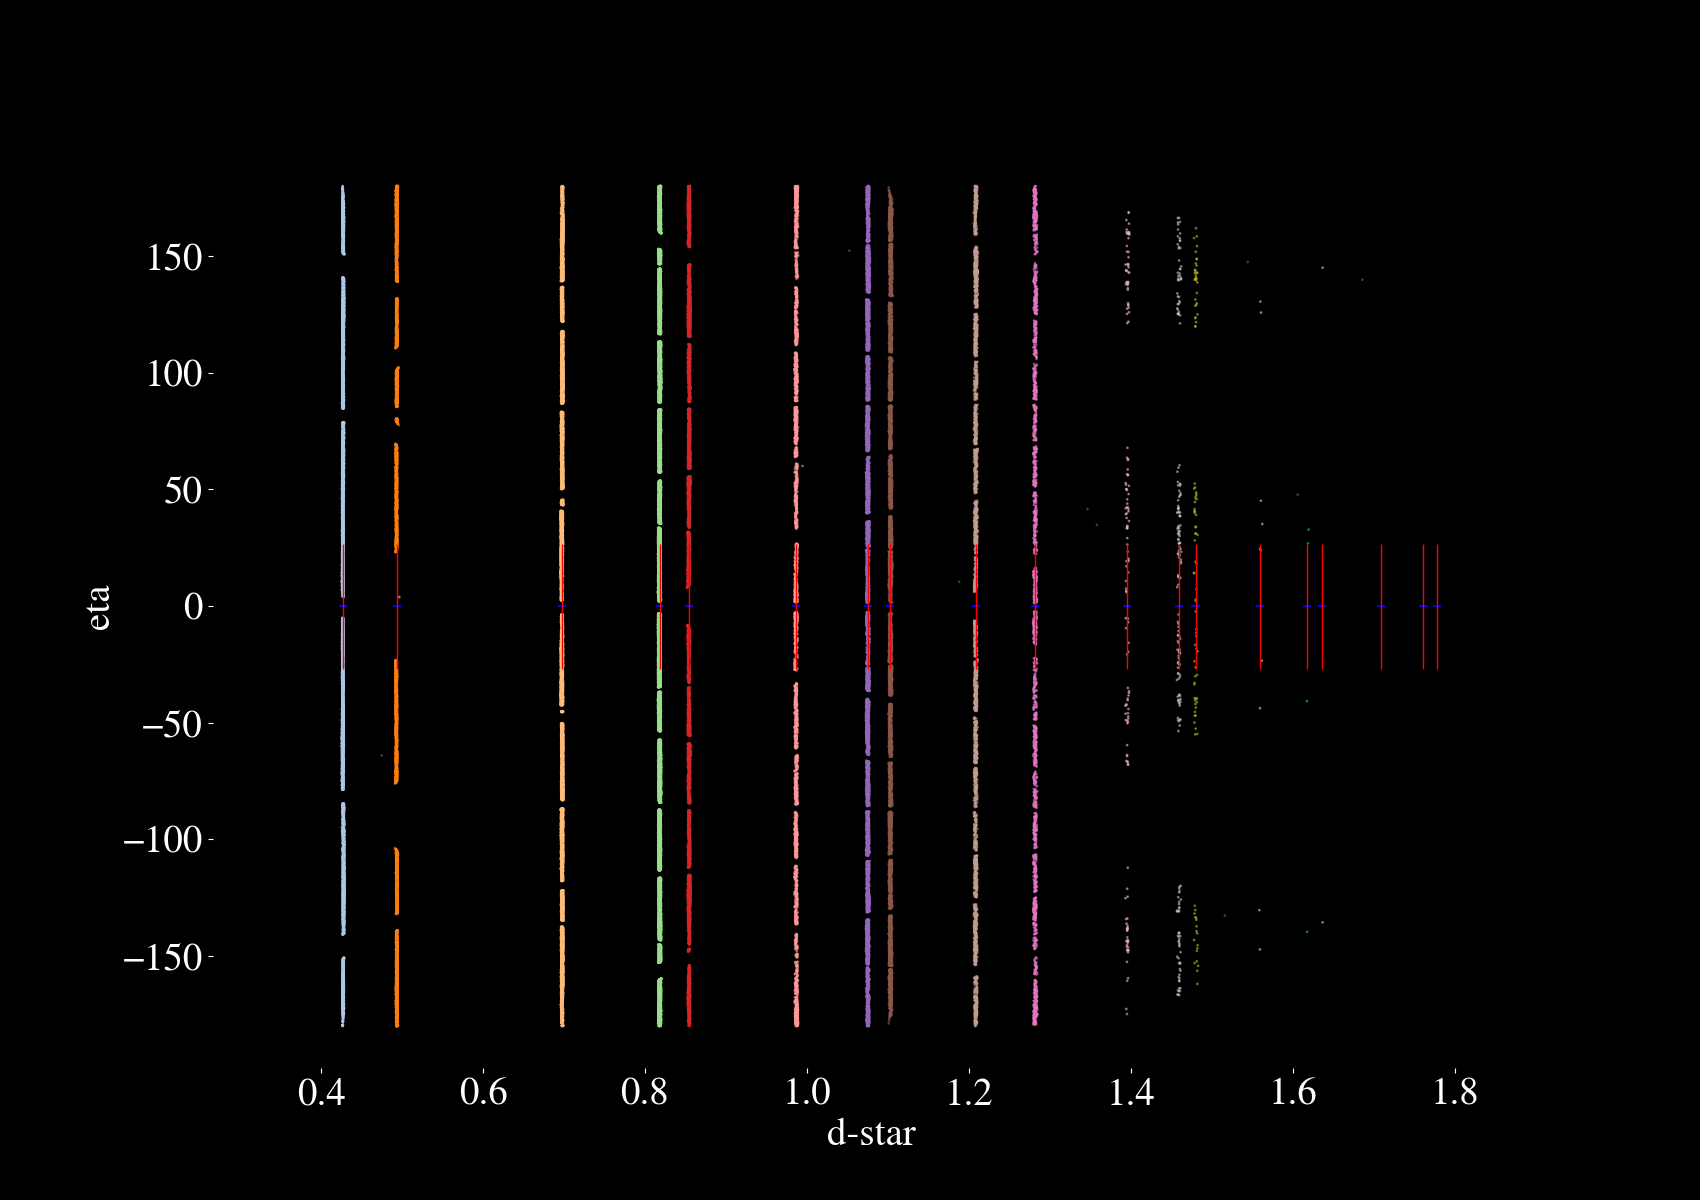

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(17, 12))
sample = np.random.permutation(colf.nrows)[:100000]
ax.scatter(colf.ds[sample], colf.eta[sample], c=indexer.ra[sample], cmap="tab20", s=1, alpha=0.5)
ds_tol = 0.01

for ucr in ucell.ringds:
    ax.hlines( 0, ucr-ds_tol/2., ucr +ds_tol/2., color="blue")

ax.plot(
    ucell.ringds,
    [
        0,
    ]
    * len(ucell.ringds),
    "|",
    ms=90,
    c="red",
)
ax.set_xlabel("d-star")
ax.set_ylabel("eta")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xlim(colf.ds.min() - 0.05, colf.ds.max() + 0.05)
plt.show()

In [28]:
sample = np.random.permutation(colf.nrows)[:1000000]

cf = {
      'sc' : colf.sc[sample],
      'fc': colf.fc[sample],
      'sum_intensity': colf.sum_intensity[sample],
      'Number_of_pixels': colf.Number_of_pixels[sample],
      'omega': colf.omega[sample], 
      'dty': colf.dty[sample] 
     }

cf = ImageD11.columnfile.colfile_from_dict(cf)
params = ImageD11.parameters.read_par_file(parpath)
cf.setparameters(params)
cf.updateGeometry()

cf.filter(np.abs(cf.eta) > 10)
cf.filter(np.abs(cf.eta) < 170)

cf.nrows

copied an array: size=1000000, elsize=4
copied an array: size=1000000, elsize=4
copied an array: size=1000000, elsize=4


886421

In [29]:
downsample_factor = 1000000 / colf.nrows
downsample_factor

0.02263004428495996

In [36]:
ImageD11.indexing.loglevel = -1

indexer = ImageD11.indexing.indexer_from_colfile(cf)
indexer.ds_tol = 0.01
indexer.assigntorings()
indexer.cosine_tol = np.cos(np.radians(90 - maptools.constants.OMEGASTEP * 1.5))
indexer.ring_1 = 0
indexer.ring_2 = 1
indexer.max_grains = 50

average_grain_diameter = 9
average_omega_peak_split = 5
everage_eta_peak_split = 3
expected_peaks = (6 + 8) * average_grain_diameter * downsample_factor * average_omega_peak_split * everage_eta_peak_split

frac = 0.8

indexer.hkl_tol = 0.03
indexer.minpks = int(expected_peaks * frac)

print("minpks", indexer.minpks)

indexer.find()  # finds trial orientations

info: gv: [[-0.45997751  0.49364594  0.72027644]
 [ 0.53999051  0.12532141  0.42217353]
 [-0.21666057  0.39997282 -0.67889948]
 ...
 [ 0.20054239  1.05523658 -0.05434919]
 [-0.11448783 -0.6233465  -0.29423268]
 [-0.08996621 -0.22591792  0.35106757]] (886421, 3) float64
info: Assign to rings, maximum d-spacing considered: 1.775964
info: Ring assignment array shape (886421,)
info: Ring     (  h,  k,  l) Mult  total indexed to_index  ubis  peaks_per_ubi   tth
info: Ring 18  (  0, -4, -6)   24      1       0        1     0     48  36.95
info: Ring 17  ( -1, -7, -1)   48      0       0        0     0     96  36.58
info: Ring 16  ( -4, -4, -4)    8      0       0        0     0     16  35.45
info: Ring 15  ( -2, -2, -6)   24     19       0       19     0     48  33.89
info: Ring 14  ( -3, -5, -3)   24     40       0       40     0     48  33.50
info: Ring 13  (  0, -6, -2)   24     67       0       67     1     48  32.27
info: Ring 12  (  0,  0, -6)   30    903       0      903    15     60 

In [37]:
indexer.scorethem()  # scores them trial orientations
np.sum(indexer.scores), len(indexer.ubis), indexer.scores

info: Scoring 139319 potential orientations
info: new grain 237 pks, i 886420 j 589660 UBI  -1.471604 -0.745842 -3.701939 -0.750303 3.952015 -0.495646 3.704386 0.509113 -1.573798
info: new grain 445 pks, i 886410 j 241716 UBI  -2.110584 1.795276 -2.961046 2.889724 -0.996634 -2.661256 -1.907492 -3.493020 -0.763098
info: new grain 243 pks, i 886396 j 636614 UBI  2.070320 2.081461 -2.795347 3.468366 -1.549118 1.422545 -0.339908 -3.116445 -2.567773
info: new grain 648 pks, i 886394 j 29210 UBI  2.212829 3.271042 -0.919388 3.316385 -2.318671 -0.266410 -0.740078 -0.603882 -3.938186
info: new grain 315 pks, i 886386 j 507819 UBI  2.029336 -3.221491 -1.390788 -3.474387 -2.062855 -0.304902 -0.465338 1.348508 -3.797267
info: new grain 357 pks, i 886381 j 433408 UBI  -0.298454 -1.211178 3.858202 2.971471 -2.682065 -0.614857 2.741783 2.782980 1.084287
info: new grain 716 pks, i 886378 j 533252 UBI  0.413020 2.653121 3.037183 2.119486 -2.742180 2.106155 3.431465 1.371456 -1.664941
info: new grain 2

(20038,
 50,
 [237,
  445,
  243,
  648,
  315,
  357,
  716,
  259,
  409,
  474,
  369,
  594,
  263,
  285,
  302,
  326,
  314,
  364,
  336,
  234,
  315,
  484,
  445,
  239,
  1032,
  314,
  440,
  553,
  385,
  453,
  245,
  425,
  465,
  357,
  671,
  687,
  342,
  426,
  326,
  282,
  332,
  327,
  292,
  339,
  260,
  539,
  368,
  284,
  373,
  548])

In [38]:
indexer.ubis

[array([[-1.47160365, -0.74584157, -3.70193918],
        [-0.75030346,  3.95201472, -0.49564624],
        [ 3.70438583,  0.5091126 , -1.57379811]]),
 array([[-2.11058412,  1.79527606, -2.96104565],
        [ 2.88972441, -0.99663383, -2.66125641],
        [-1.90749151, -3.49302042, -0.76309774]]),
 array([[ 2.07031957,  2.08146092, -2.7953474 ],
        [ 3.46836618, -1.54911796,  1.42254527],
        [-0.33990824, -3.11644456, -2.56777328]]),
 array([[ 2.21282902,  3.27104164, -0.91938783],
        [ 3.31638475, -2.31867135, -0.26640974],
        [-0.74007764, -0.60388223, -3.93818605]]),
 array([[ 2.02933643, -3.2214914 , -1.39078782],
        [-3.47438727, -2.06285484, -0.30490163],
        [-0.46533807,  1.34850837, -3.79726701]]),
 array([[-0.29845366, -1.211178  ,  3.85820176],
        [ 2.97147051, -2.68206451, -0.6148567 ],
        [ 2.74178301,  2.78298044,  1.08428666]]),
 array([[ 0.41301976,  2.6531209 ,  3.03718319],
        [ 2.11948573, -2.74218044,  2.10615483],
        

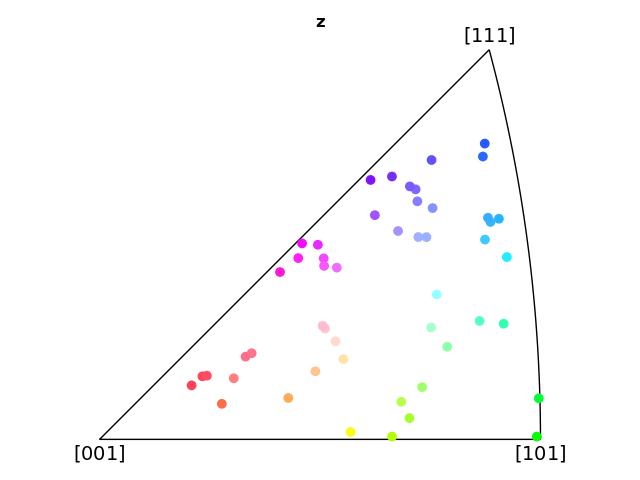

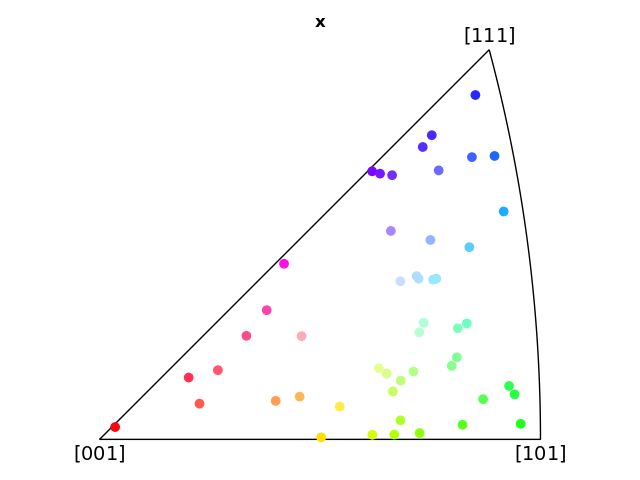

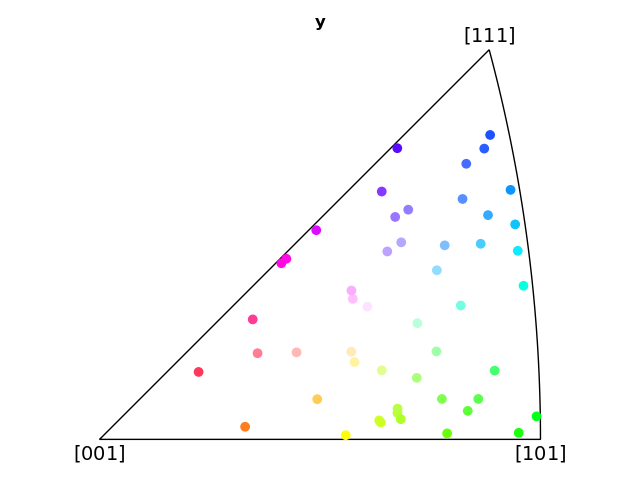

In [39]:
from ImageD11.nbGui import nb_utils as utils

grains = [ImageD11.grain.grain(ubi) for ubi in indexer.ubis]
for g in grains:
    g.ref_unitcell = ucell
plt.style.use("default")
utils.plot_all_ipfs(grains)
plt.show()